In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-04-12 21:13:39.236071: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-12 21:13:39.294901: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-12 21:13:39.324324: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744506819.375502     577 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744506819.387902     577 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-12 21:13:39.476743: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [107]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

In [446]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('PMAP_Predictors2.csv')

    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time'])
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [447]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = True) 

In [448]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [449]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('variance', myVariance), ('imputer', myImputer), ('covariates', myCovariates)]

In [450]:
X_train = X_train.loc[:, X_train.isnull().mean() < 0.2]
X_test = X_test[X_train.columns]

In [451]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [452]:
X_test_transf.columns

Index(['keep__keep__bin__hypothermia', 'remainder__pca0', 'remainder__pca1',
       'remainder__pca2', 'remainder__pca3', 'remainder__pca4',
       'remainder__pca5', 'remainder__pca6', 'remainder__pca7',
       'remainder__pca8',
       ...
       'remainder__pca629', 'remainder__pca630', 'remainder__pca631',
       'remainder__pca632', 'remainder__pca633', 'remainder__pca634',
       'remainder__pca635', 'remainder__pca636', 'remainder__pca637',
       'remainder__pca638'],
      dtype='object', length=640)

In [453]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [454]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=15, batch_size=8, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4680 - loss: 0.8126 - roc_auc: 0.5454 - val_accuracy: 0.7552 - val_loss: 0.5773 - val_roc_auc: 0.7617
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6758 - loss: 0.5854 - roc_auc: 0.7215 - val_accuracy: 0.8222 - val_loss: 0.4857 - val_roc_auc: 0.8243
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4848 - roc_auc: 0.7883 - val_accuracy: 0.8273 - val_loss: 0.4392 - val_roc_auc: 0.8429
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8368 - loss: 0.4063 - roc_auc: 0.8779 - val_accuracy: 0.8351 - val_loss: 0.4123 - val_roc_auc: 0.8491
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8903 - loss: 0.3372 - roc_auc: 0.9324 - val_accuracy: 0.8351 - val_loss: 0.3966 - val_roc_auc: 0.8536
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9166 - loss: 0.2918 - roc_auc: 0.9485 - val_accuracy: 0.8273 - val_loss: 0.3877 - val_roc_auc:

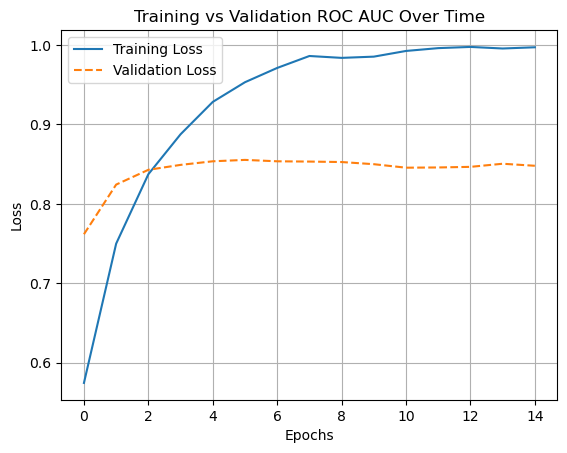

In [455]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [456]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
ROC AUC Score: 0.8480


In [457]:
y_pred_probs.T[0, :]

array([4.32048067e-02, 2.04630494e-02, 1.85265243e-01, 1.09397555e-02,
       7.51472488e-02, 7.62005210e-01, 8.12812895e-02, 1.25472164e-02,
       3.64961326e-02, 3.57714569e-04, 2.25278977e-02, 2.14174870e-04,
       6.23546205e-02, 7.97866046e-01, 1.59955944e-03, 8.75194848e-01,
       6.30001247e-01, 5.39062381e-01, 1.30700637e-02, 6.66974410e-02,
       8.02701786e-02, 2.04353686e-03, 5.13967825e-04, 8.71184051e-01,
       1.52093470e-02, 1.28359871e-03, 3.88607867e-02, 4.22158428e-02,
       7.67070043e-04, 2.12259486e-01, 6.93704635e-02, 9.22551006e-03,
       3.13370496e-01, 1.35761956e-02, 9.84536633e-02, 5.14163869e-04,
       3.17062577e-03, 8.75881035e-03, 2.30807299e-03, 6.52814191e-03,
       1.14634458e-03, 1.28432363e-02, 1.81990042e-02, 2.64066327e-02,
       4.31246031e-03, 4.02575225e-01, 1.29126001e-03, 1.34170521e-02,
       1.90195919e-03, 9.67096567e-01, 1.05180014e-02, 2.29346938e-03,
       7.06695369e-04, 9.93828952e-01, 7.33065512e-03, 1.20333629e-02,
      

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Optimization terminated successfully.
         Current function value: 0.546574
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.546084
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.8860052282850575
p-value: 0.6421055285302312
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  904
Model:                          Logit   Df Residuals:                      900
Method:                           MLE   Df Model:                            3
Date:                Sat, 12 Apr 2025   Pseudo R-squ.:                 0.01727
Time:                        23:34:39   Log-Likelihood:                -494.10
converged:                       True   LL-Null:                       -502.78
Covariance Type:     

0.6421055285302312

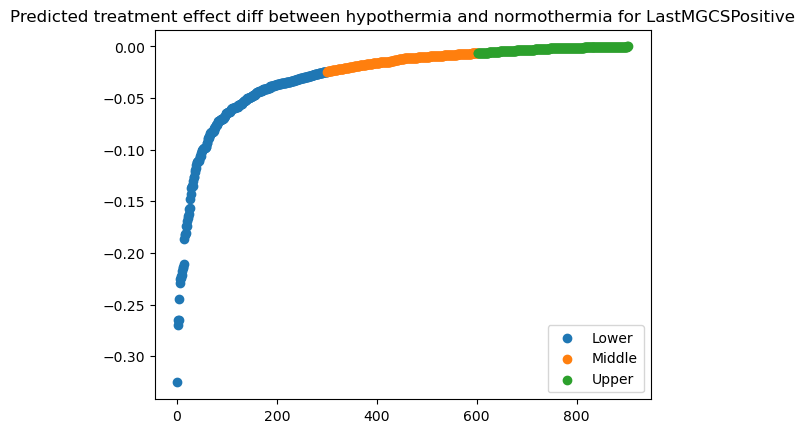

In [460]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'LastMGCSPosutive', aGroup = 'keep__keep__bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


PatsyError: Error evaluating factor: NameError: name 'death_at_disch' is not defined
    death_at_disch ~ predicted_effect + TreatmentColumn
    ^^^^^^^^^^^^^^

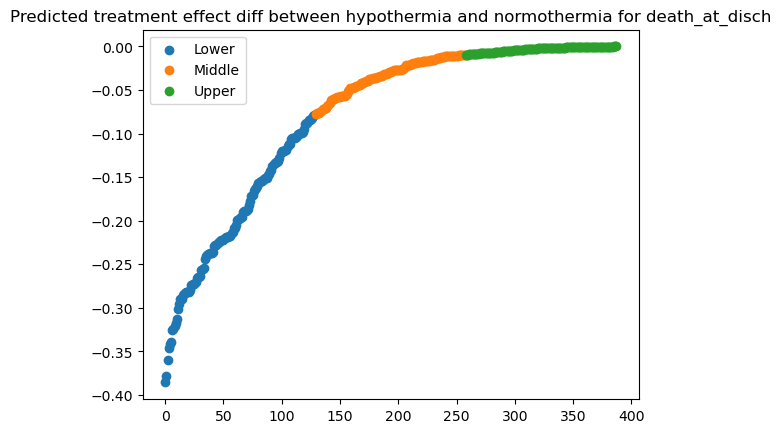

In [459]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'death_at_disch', aGroup = 'keep__keep__bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined